# AI Startup Sucsess Predictor
## Data Understanding & Preprocessing
### Dataset:
Startup Success/Fail Dataset from Crunchbase
### Objective:
The objective of this notebook is to understand, clean, analyze, and preprocess the startup dataset to prepare it for machine learning modeling.

In [ ]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
plt.style.use("ggplot")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [138]:
#load dataset
df = pd.read_csv("big_startup_secsees_dataset.csv")

In [139]:
df.head(10)

,permalink,name,homepage_url,category_list,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,first_funding_at,last_funding_at
0,/organization/-fame,#fame,http://livfame.com,Media,10000000,operating,IND,16,Mumbai,Mumbai,1,NaN,2015-01-05,2015-01-05
1,/organization/-qounter,:Qounter,http://www.qounter.com,Application Platforms|Real Time|Social Network...,700000,operating,USA,DE,DE - Other,Delaware City,2,2014-09-04,2014-03-01,2014-10-14
2,/organization/-the-one-of-them-inc-,"(THE) ONE of THEM,Inc.",http://oneofthem.jp,Apps|Games|Mobile,3406878,operating,NaN,NaN,NaN,NaN,1,NaN,2014-01-30,2014-01-30
3,/organization/0-6-com,0-6.com,http://www.0-6.com,Curated Web,2000000,operating,CHN,22,Beijing,Beijing,1,2007-01-01,2008-03-19,2008-03-19
4,/organization/004-technologies,004 Technologies,http://004gmbh.de/en/004-interact,Software,-,operating,USA,IL,"Springfield, Illinois",Champaign,1,2010-01-01,2014-07-24,2014-07-24
5,/organization/01games-technology,01Games Technology,http://www.01games.hk/,Games,41250,operating,HKG,NaN,Hong Kong,Hong Kong,1,NaN,2014-07-01,2014-07-01
6,/organization/0ndine-biomedical-inc,Ondine Biomedical Inc.,http://ondinebio.com,Biotechnology,762851,operating,CAN,BC,Vancouver,Vancouver,2,1997-01-01,2009-09-11,2009-12-21
7,/organization/0xdata,H2O.ai,http://h2o.ai/,Analytics,33600000,operating,USA,CA,SF Bay Area,Mountain View,4,2011-01-01,2013-01-03,2015-11-09
8,/organization/1,One Inc.,http://whatis1.com,Mobile,1150050,operating,USA,CA,SF Bay Area,San Francisco,3,2011-08-01,2011-07-20,2014-02-05
9,/organization/1-2-3-listo,"1,2,3 Listo",http://www.123listo.com,E-Commerce,40000,operating,CHL,12,Santiago,Las Condes,1,2012-01-01,2013-02-18,2013-02-18


# Data Understanding
In this section, we explore the structure of the dataset, inspect its dimensions, data types, and obtain a general understanding of the available features before performing any preprocessing.

In [140]:
df.shape

(66368, 14)

In [141]:
df.sample(5)

,permalink,name,homepage_url,category_list,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,first_funding_at,last_funding_at
9629,/organization/car-rentals-market,Car Rentals Market,http://www.carrentalsmarket.com,Automotive|Cars|Internet|Online Rental|Public ...,300000,operating,USA,CA,SF Bay Area,San Francisco,2,2013-03-03,2013-03-10,2014-01-07
63626,/organization/wested,​WestEd,http://www.wested.org/,Nonprofits,3000000,operating,USA,CA,SF Bay Area,San Francisco,1,NaN,2014-07-22,2014-07-22
22266,/organization/garageskins,GarageSkins,http://www.garageskins.com/,NaN,-,operating,USA,OR,Eugene,Creswell,1,2012-11-15,2014-04-02,2014-04-02
50545,/organization/senior-cottage,Senior Cottage,http://www.senior-cottage.fr,Elder Care|Elderly|Social Innovation,3013403,operating,FRA,A8,Paris,Paris,2,2013-02-27,2014-03-01,2015-03-15
10062,/organization/caspian-learning,Caspian Learning,http://www.caspianlearning.co.uk,Software,4450000,operating,GBR,NaN,NaN,NaN,2,NaN,2005-04-04,2008-06-23


In [142]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66368 entries, 0 to 66367
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   permalink          66368 non-null  object
 1   name               66367 non-null  object
 2   homepage_url       61310 non-null  object
 3   category_list      63220 non-null  object
 4   funding_total_usd  66368 non-null  object
 5   status             66368 non-null  object
 6   country_code       59410 non-null  object
 7   state_code         57821 non-null  object
 8   region             58338 non-null  object
 9   city               58340 non-null  object
 10  funding_rounds     66368 non-null  int64 
 11  founded_at         51147 non-null  object
 12  first_funding_at   66344 non-null  object
 13  last_funding_at    66368 non-null  object
dtypes: int64(1), object(13)
memory usage: 7.1+ MB


In [143]:
df.describe(include='all')

,permalink,name,homepage_url,category_list,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,first_funding_at,last_funding_at
count,66368,66367,61310,63220,66368,66368,59410,57821,58338,58340,66368.000000,51147,66344,66368
unique,66368,66102,61191,27296,18896,4,137,311,1092,5111,NaN,3978,4817,4518
top,/organization/-fame,Blink,http://www.askforoffer.com,Software,-,operating,USA,CA,SF Bay Area,San Francisco,NaN,2012-01-01,2014-01-01,2014-01-01
freq,1,4,5,3995,12785,53034,37601,12900,8804,3526,NaN,2730,565,483
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.732522,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.360251,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN


In [144]:
df['status'].value_counts()

status
operating    53034
closed        6238
acquired      5549
ipo           1547
Name: count, dtype: int64

we have imbalance and multi-class classifcation
we can not depand on acc only ,so we will use precision, recall, f1, con matrix

In [145]:
df.head()

,permalink,name,homepage_url,category_list,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,first_funding_at,last_funding_at
0,/organization/-fame,#fame,http://livfame.com,Media,10000000,operating,IND,16,Mumbai,Mumbai,1,NaN,2015-01-05,2015-01-05
1,/organization/-qounter,:Qounter,http://www.qounter.com,Application Platforms|Real Time|Social Network...,700000,operating,USA,DE,DE - Other,Delaware City,2,2014-09-04,2014-03-01,2014-10-14
2,/organization/-the-one-of-them-inc-,"(THE) ONE of THEM,Inc.",http://oneofthem.jp,Apps|Games|Mobile,3406878,operating,NaN,NaN,NaN,NaN,1,NaN,2014-01-30,2014-01-30
3,/organization/0-6-com,0-6.com,http://www.0-6.com,Curated Web,2000000,operating,CHN,22,Beijing,Beijing,1,2007-01-01,2008-03-19,2008-03-19
4,/organization/004-technologies,004 Technologies,http://004gmbh.de/en/004-interact,Software,-,operating,USA,IL,"Springfield, Illinois",Champaign,1,2010-01-01,2014-07-24,2014-07-24


# Missing Values Analysis

Before handling missing values, we first identify the number and percentage of missing values in each feature to determine the most appropriate preprocessing strategy.

In [146]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage":(df.isnull().sum()/len(df)*100)
})

missing.sort_values("Percentage", ascending=False)

,Missing Values,Percentage
founded_at,15221,22.934245
state_code,8547,12.878194
region,8030,12.099204
city,8028,12.096191
country_code,6958,10.483968
homepage_url,5058,7.621143
category_list,3148,4.743250
first_funding_at,24,0.036162
name,1,0.001507
permalink,0,0.000000


## Missing Values Analysis

The dataset contains missing values across several features\

- Features such as 'name' and 'first_funding_at' contain very few missing values and can be handled easily.
- some features have a moderate percentage of missing values (around 5-13%), requiring careful evaluation before deciding impute or remove them.
- The 'founded_at' feature has the highest missing percentage (~23%) , but it may still provide valuable information for feature engineering.
- No preprocessing decisions will be made until the importance of each feature is evaluated.

In [147]:
df.nunique().sort_values()

status                   4
funding_rounds          19
country_code           137
state_code             311
region                1092
founded_at            3978
last_funding_at       4518
first_funding_at      4817
city                  5111
funding_total_usd    18896
category_list        27296
homepage_url         61191
name                 66102
permalink            66368
dtype: int64

## Feature Cardinality Analysis

To better understand the characteristics of each feature, we examined the number of unique values in every column.

### Observations

- The **status** column contains **4 unique values**, confirming that the problem is a **multi-class classification** task.

- The **funding_rounds** feature has only **19 unique values**, making it a low-cardinality numerical feature that is likely to be informative for prediction.

- The **country_code** and **state_code** features contain a moderate number of unique values and may provide useful geographical information.

- The **region** and **city** features have a relatively high number of unique values, which may require careful encoding before model training.

- The **category_list** feature has **27,296 unique values** because many companies belong to multiple categories. This feature will require special preprocessing instead of simple label encoding.

- The **permalink**, **name**, and **homepage_url** columns have extremely high cardinality. These columns primarily serve as identifiers rather than descriptive business features and are unlikely to contribute meaningful predictive information.

# Duplicate Records Analysis

Duplicate records can negatively affect the performance of machine learning models by introducing redundant information and bias.

In this step, we check whether the dataset contains duplicate rows before performing any cleaning operations.

In [148]:
df.duplicated().sum()

np.int64(0)

## Observations

- The dataset does not contain any duplicate records.
- Each row represents a unique startup.
- No duplicate removal is required at this stage.

### Decision

No duplicate records were found in the dataset. Therefore, no rows were removed during this step.

# Funding Amount Inspection

The `funding_total_usd` feature should represent a numerical value.

Since it is currently stored as an object, we inspect its values to identify any formatting issues before converting it into a numeric feature.

In [149]:
df["funding_total_usd"].sample(20)

46497      100000
65350      100000
23958     6000000
30194      890000
37053     1100000
52411     5000000
41688           -
31588       75000
5049      3500000
31928     1000000
12682     2345000
43990    18349996
50913      500000
30997           -
51313    21350000
35809     1000000
34463           -
60643           -
9004      1000000
54761    14000000
Name: funding_total_usd, dtype: object

## Funding Amount Inspection
## Observation
- The 'funding_total_usd' feature contains numerical values stored as text
- Some recorde use '-' instead of numeric value, indicating missing or unavailable funding information.
- These values must be handled before converting the feature to a numeric type.

In [150]:
(df["funding_total_usd"]=="-").sum()

np.int64(12785)

In [151]:
(df["funding_total_usd"]=="-").mean()*100

np.float64(19.263801832208294)

## Missing Funding Values Analysis

### Observations

- The `funding_total_usd` feature contains **3,572** records represented by `-`.
- These values account for approximately **18.8%** of the dataset.
- Since this percentage is relatively high, removing these rows would result in a significant loss of data.
- Therefore, these values will be treated as missing values (`NaN`) and handled appropriately instead of deleting the corresponding records.

In [152]:
df[['permalink','name','homepage_url']].head(10)

,permalink,name,homepage_url
0,/organization/-fame,#fame,http://livfame.com
1,/organization/-qounter,:Qounter,http://www.qounter.com
2,/organization/-the-one-of-them-inc-,"(THE) ONE of THEM,Inc.",http://oneofthem.jp
3,/organization/0-6-com,0-6.com,http://www.0-6.com
4,/organization/004-technologies,004 Technologies,http://004gmbh.de/en/004-interact
5,/organization/01games-technology,01Games Technology,http://www.01games.hk/
6,/organization/0ndine-biomedical-inc,Ondine Biomedical Inc.,http://ondinebio.com
7,/organization/0xdata,H2O.ai,http://h2o.ai/
8,/organization/1,One Inc.,http://whatis1.com
9,/organization/1-2-3-listo,"1,2,3 Listo",http://www.123listo.com


# Feature Selection

Some features were identified as unique identifiers rather than informative business attributes.

### Removed Features

- **permalink**: A unique identifier for each startup.
- **name**: Company names are highly unique and do not provide meaningful predictive information.
- **homepage_url**: Website URLs are unique identifiers and are not expected to contribute to predicting startup outcomes.

### Decision

These features were removed to reduce noise and simplify the dataset without losing relevant business information.

In [153]:
df.drop(columns=['permalink','name','homepage_url'], inplace=True)

In [154]:
df.head()

,category_list,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,first_funding_at,last_funding_at
0,Media,10000000,operating,IND,16,Mumbai,Mumbai,1,NaN,2015-01-05,2015-01-05
1,Application Platforms|Real Time|Social Network...,700000,operating,USA,DE,DE - Other,Delaware City,2,2014-09-04,2014-03-01,2014-10-14
2,Apps|Games|Mobile,3406878,operating,NaN,NaN,NaN,NaN,1,NaN,2014-01-30,2014-01-30
3,Curated Web,2000000,operating,CHN,22,Beijing,Beijing,1,2007-01-01,2008-03-19,2008-03-19
4,Software,-,operating,USA,IL,"Springfield, Illinois",Champaign,1,2010-01-01,2014-07-24,2014-07-24


# Data Type Conversion

## Funding Total (USD)

The `funding_total_usd` feature is expected to contain numerical values representing the total funding received by each startup.

However, some records contain the symbol `-`, which represents missing or unavailable values. Therefore, these values will first be converted to `NaN`, and then the column will be converted to a numeric data type.

In [155]:
df["funding_total_usd"]=df["funding_total_usd"].replace("-", np.nan)

In [156]:
df["funding_total_usd"]=pd.to_numeric(df["funding_total_usd"])

In [157]:
df["funding_total_usd"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 66368 entries, 0 to 66367
Series name: funding_total_usd
Non-Null Count  Dtype  
--------------  -----  
53583 non-null  float64
dtypes: float64(1)
memory usage: 518.6 KB


In [158]:
df["funding_total_usd"].describe()

count    5.358300e+04
mean     1.847860e+07
std      1.880133e+08
min      1.000000e+00
25%      3.356235e+05
50%      2.000000e+06
75%      1.000000e+07
max      3.007950e+10
Name: funding_total_usd, dtype: float64

In [159]:
df["funding_total_usd"].isna().sum()

np.int64(12785)

In [160]:
df.shape

(66368, 11)

# EDA
## Target Variable Analynsis
Before exploring the input features, it is important to understand the distribution of the target variable('status').

This helps us identify whether the classes are blanced or imbalanced, which may influence model selection and evaluation metrics.

In [161]:
status_counts = df["status"].value_counts()
status_counts

status
operating    53034
closed        6238
acquired      5549
ipo           1547
Name: count, dtype: int64

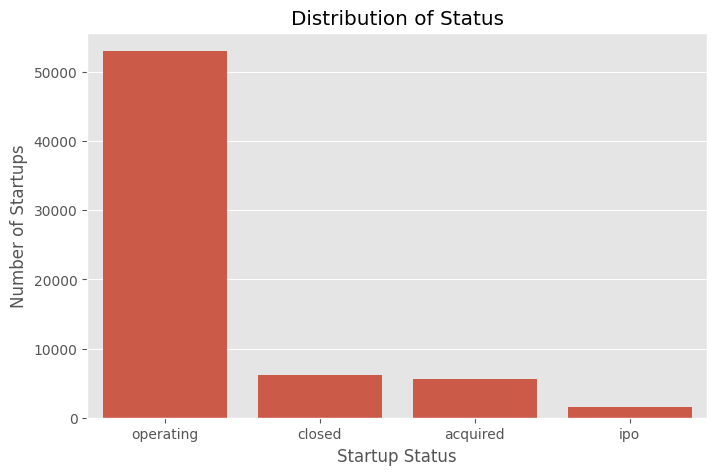

In [162]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x="status",
    order=status_counts.index
)

plt.title("Distribution of Status")
plt.xlabel("Startup Status")
plt.ylabel("Number of Startups")
plt.show()

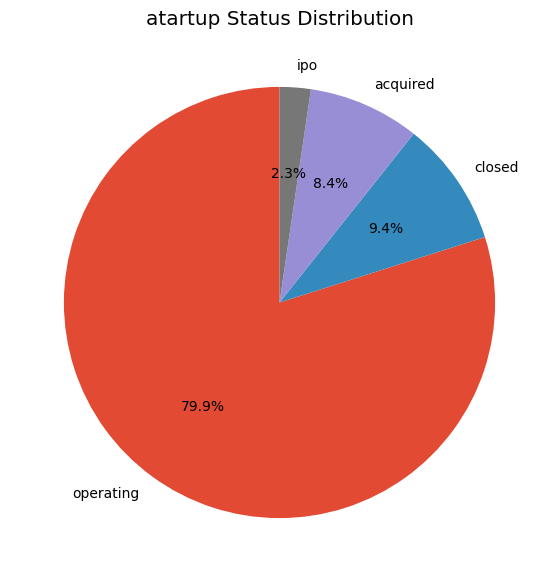

In [163]:
plt.figure(figsize=(7,7))
plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct="%1.1f%%",
    startangle=90,

)
plt.title("atartup Status Distribution")
plt.show()

### EDA Insights: Target Variable Distribution
- The distribution shows that the majority of startups are 'Operating'.
- A smaller percentage successfully reached an 'IPO' or were 'Acquired', while a notable portion 'Closed'.
- **Note:** This class imbalance should be considered by the Machine Learning engineer during modeling (e.g., using SMOTE or Class Weights).

## Observations

- The dataset contains four startup status categories:
  - Operating
  - Closed
  - Acquired
  - IPO

- The majority of startups (approximately **80%**) are still operating.

- IPO companies represent the smallest class (around **2%** of the dataset).

- The target variable is clearly **imbalanced**, with a significant difference between the majority and minority classes.

- This confirms that the problem is a **multi-class classification** task rather than binary classification.

## Business Insight

The distribution suggests that most startups remain in the operating stage, while only a small percentage either become publicly listed (IPO), get acquired, or shut down.

This reflects the real-world startup ecosystem, where reaching an IPO is relatively rare compared to continuing normal business operations.

## Decision

The target variable is imbalanced.

During the modeling phase, we will avoid relying solely on **Accuracy** as the evaluation metric.

Instead, we will also evaluate models using:

- Precision
- Recall
- F1-score
- Confusion Matrix

If necessary, class balancing techniques (such as class weights or resampling) may be considered.

## Funding Amount vs Startup Status

### Objective

Analyze whether the total funding received by a startup differs across different startup outcomes.

This analysis helps determine whether funding amount is an informative feature for predicting startup success.

In [164]:
df.groupby("status")["funding_total_usd"].describe()

,count,mean,std,min,25%,50%,75%,max
status,,,,,,,,
acquired,4790.0,2.829304e+07,1.280034e+08,1500.0,2990956.75,10000000.0,26785659.5,5.820000e+09
closed,4912.0,1.089794e+07,4.380889e+07,2.0,200000.00,1250000.0,7000000.0,1.567504e+09
ipo,1441.0,1.457052e+08,9.882934e+08,4000.0,9400000.00,30675796.0,94100000.0,3.007950e+10
operating,42440.0,1.392845e+07,9.396951e+07,1.0,270803.50,1520832.0,7771325.0,1.066494e+10


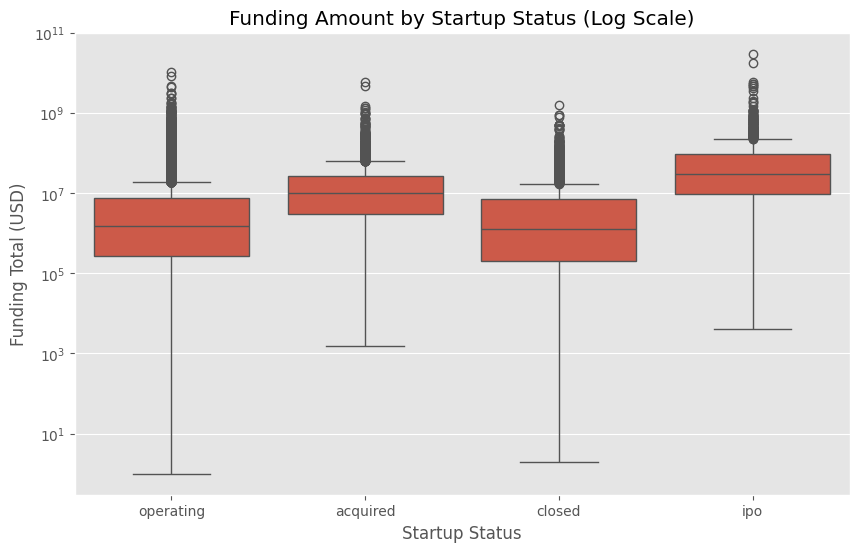

In [165]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="status",
    y="funding_total_usd"
)

plt.yscale("log")

plt.title("Funding Amount by Startup Status (Log Scale)")
plt.xlabel("Startup Status")
plt.ylabel("Funding Total (USD)")

plt.show()

### EDA Insights: Funding Amount vs Status
- Using a log scale reveals extreme outliers in funding amounts, which is highly characteristic of the startup ecosystem.
- Startups that reach an 'IPO' have significantly higher median funding compared to other statuses.
- 'Closed' startups generally have the lowest funding amounts.

## Observations

- IPO startups received the highest funding amounts among all startup statuses.
- Closed startups generally received the lowest funding.
- Acquired startups also tend to receive higher funding than operating startups.
- The funding distribution is highly right-skewed, with many extreme values (outliers).
- The median provides a better measure of central tendency than the mean because the data contains many large funding values.

## Business Insight

The analysis suggests that funding is strongly associated with startup outcomes.

Startups that eventually reach an IPO or are acquired generally receive substantially higher funding than companies that close.

This indicates that funding may be an important predictive feature in the machine learning model.

## Decision

- Keep the `funding_total_usd` feature because it appears to contain valuable predictive information.
- Do not remove outliers at this stage because they represent legitimate startup funding events.
- Use the median instead of the mean when handling missing values due to the highly skewed distribution.

## Funding Rounds vs Startup Status

### Objective

Analyze whether the number of funding rounds differs across startup outcomes.

This helps determine whether funding activity is associated with startup success.

In [166]:
df.groupby("status")["funding_rounds"].describe()

,count,mean,std,min,25%,50%,75%,max
status,,,,,,,,
acquired,5549.0,2.116778,1.550073,1.0,1.0,2.0,3.0,18.0
closed,6238.0,1.399006,0.964154,1.0,1.0,1.0,1.0,14.0
ipo,1547.0,2.796380,2.336623,1.0,1.0,2.0,4.0,16.0
operating,53034.0,1.700513,1.316464,1.0,1.0,1.0,2.0,19.0


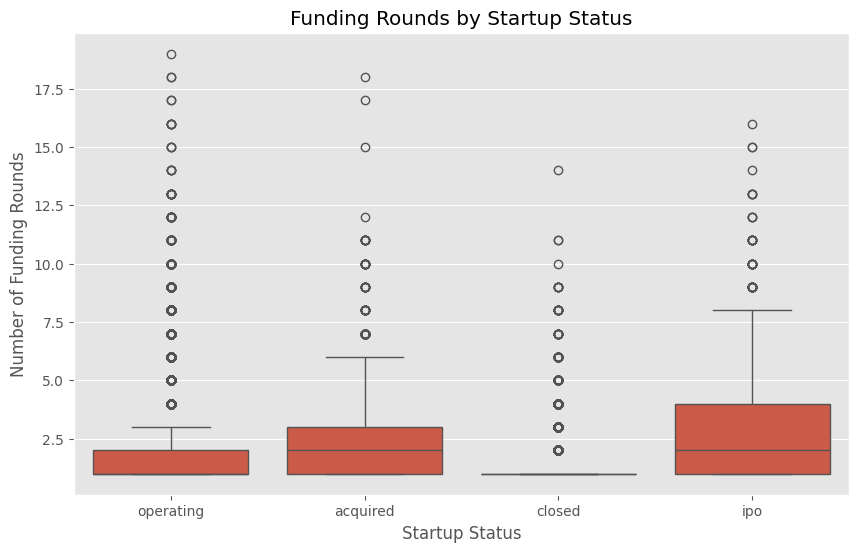

In [167]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="status",
    y="funding_rounds"
)

plt.title("Funding Rounds by Startup Status")
plt.xlabel("Startup Status")
plt.ylabel("Number of Funding Rounds")

plt.show()

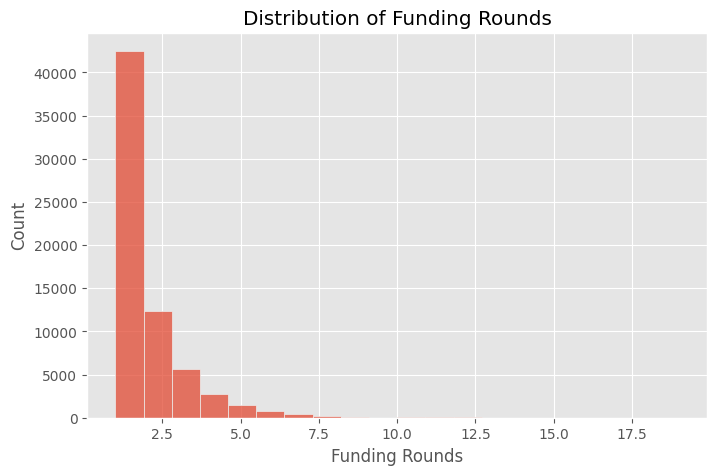

In [168]:
plt.figure(figsize=(8,5))

sns.histplot(df["funding_rounds"], bins=20)

plt.title("Distribution of Funding Rounds")
plt.xlabel("Funding Rounds")
plt.ylabel("Count")

plt.show()

## Funding Rounds vs Startup Status

### Objective

Analyze whether startups with more funding rounds tend to achieve better outcomes such as acquisition or IPO.

## Observations

- IPO and acquired startups generally participate in more funding rounds than operating or closed startups.
- Most closed startups received only one funding round.
- The distribution contains several high-value observations, but these represent legitimate business cases rather than data errors.
- The funding rounds feature appears to differentiate startup outcomes.

## Business Insight

The number of funding rounds reflects investor confidence over time.

Startups that successfully secure multiple funding rounds are more likely to be acquired or reach an IPO, while startups that fail often stop after the first funding round.

## Decision

- Keep the `funding_rounds` feature.
- Do not remove high funding-round observations.
- This feature is expected to contribute positively to the prediction model.

# Data Cleaning

# Removing High-Cardinality Location Features

## Objective

Remove location features that are highly detailed and contain many unique values.

These columns increase model complexity while providing limited predictive value compared to the country-level information.

In [169]:
df.drop(columns=["state_code","region","city"], inplace=True)

In [170]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66368 entries, 0 to 66367
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   category_list      63220 non-null  object 
 1   funding_total_usd  53583 non-null  float64
 2   status             66368 non-null  object 
 3   country_code       59410 non-null  object 
 4   funding_rounds     66368 non-null  int64  
 5   founded_at         51147 non-null  object 
 6   first_funding_at   66344 non-null  object 
 7   last_funding_at    66368 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 4.1+ MB


# Date Features Preparation

## Objective

Convert date columns into datetime format to enable feature engineering and time-based analysis.

In [171]:
date_columns = ["founded_at","first_funding_at","last_funding_at"]

for col in date_columns:
  df[col] = pd.to_datetime(df[col],errors="coerce")

In [172]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66368 entries, 0 to 66367
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   category_list      63220 non-null  object        
 1   funding_total_usd  53583 non-null  float64       
 2   status             66368 non-null  object        
 3   country_code       59410 non-null  object        
 4   funding_rounds     66368 non-null  int64         
 5   founded_at         51143 non-null  datetime64[ns]
 6   first_funding_at   66341 non-null  datetime64[ns]
 7   last_funding_at    66368 non-null  datetime64[ns]
dtypes: datetime64[ns](3), float64(1), int64(1), object(3)
memory usage: 4.1+ MB


# Feature Engineering

## Objective

Create new meaningful features from existing date columns.

Instead of using raw dates directly, we will extract information that better represents a startup's lifecycle and may improve the predictive performance of the machine learning model.

In [173]:
df["last_funding_at"].dt.year.max()

np.int32(2115)

In [174]:
df[df["last_funding_at"].dt.year > 2025][["last_funding_at"]]

,last_funding_at
46956,2105-05-01
63921,2115-12-01


## Data Quality Check

While exploring the date columns, two records were found with unrealistic future dates (2105 and 2115).

Since these dates are impossible for the dataset timeline, they are considered data entry errors and will be treated as missing values.

In [175]:
df.loc[df["last_funding_at"].dt.year > 2025, "last_funding_at"] = pd.NaT

In [176]:
REFERENCE_YEAR = df["last_funding_at"].dt.year.max()
REFERENCE_YEAR

np.float64(2015.0)

## Reference Year

The latest valid funding year in the dataset is **2015**.

This year will be used as the reference point for creating time-based features instead of using the current year, ensuring that the analysis remains reproducible.

In [177]:
# feature 1
df["company_age"] = ( REFERENCE_YEAR - df["founded_at"].dt.year)

In [178]:
df[["founded_at","company_age"]].head(10)

,founded_at,company_age
0,NaT,NaN
1,2014-09-04,1.0
2,NaT,NaN
3,2007-01-01,8.0
4,2010-01-01,5.0
5,NaT,NaN
6,1997-01-01,18.0
7,2011-01-01,4.0
8,2011-08-01,4.0
9,2012-01-01,3.0


In [179]:
df["company_age"].describe()

count    51143.000000
mean         7.237706
std         10.302143
min        -90.000000
25%          2.000000
50%          5.000000
75%          9.000000
max        266.000000
Name: company_age, dtype: float64

In [180]:
df[df["company_age"] < 0][["founded_at", "company_age"]]

,founded_at,company_age
16681,2105-02-17,-90.0
30842,2016-01-01,-1.0
32736,2041-09-21,-26.0
34438,2016-04-02,-1.0
53396,2104-01-01,-89.0


In [181]:
df[df["company_age"] > 100][["founded_at", "company_age"]]

,founded_at,company_age
1879,1899-12-31,116.0
2353,1871-01-01,144.0
2952,1869-01-01,146.0
2959,1881-05-01,134.0
3736,1889-01-01,126.0
...,...,...
64340,1865-01-01,150.0
64679,1831-01-01,184.0
64755,1906-01-01,109.0
65966,1902-01-01,113.0


In [182]:
df[df["company_age"] < 0][["founded_at", "company_age"]]

,founded_at,company_age
16681,2105-02-17,-90.0
30842,2016-01-01,-1.0
32736,2041-09-21,-26.0
34438,2016-04-02,-1.0
53396,2104-01-01,-89.0


In [183]:
print("Founded:", df["founded_at"].max())
print("First Funding:", df["first_funding_at"].max())
print("Last Funding:", df["last_funding_at"].max())

Founded: 2105-02-17 00:00:00
First Funding: 2015-12-05 00:00:00
Last Funding: 2015-12-12 00:00:00


## Invalid Company Ages

Some companies have a negative age, which means their founding date is after our reference year (2015). This is a data entry error. We will treat these invalid ages as missing values.
There are also a few startups with an age over 100 years, which is very unlikely for the type of companies in this dataset. We will also treat these as missing values.

In [184]:
df.loc[df["company_age"] < 0, "company_age"] = np.nan
df.loc[df["company_age"] > 100, "company_age"] = np.nan

## More Feature Engineering

Let's create more features from the date columns to capture more information about the startup's timeline.

- **Funding Duration:** The time between the first and last funding rounds.
- **Time to First Funding:** The time between the founding date and the first funding round.

In [185]:
df["funding_duration_days"] = (df["last_funding_at"] - df["first_funding_at"]).dt.days
df["time_to_first_funding_days"] = (df["first_funding_at"] - df["founded_at"]).dt.days

Let's check the new features.

In [186]:
df[["funding_duration_days", "time_to_first_funding_days"]].describe()

,funding_duration_days,time_to_first_funding_days
count,66339.000000,51120.000000
mean,341.166599,1370.135407
std,683.860259,3559.220449
min,0.000000,-33055.000000
25%,0.000000,144.000000
50%,0.000000,516.000000
75%,415.500000,1369.000000
max,17287.000000,93053.000000


Some of these new features also have negative values, which is impossible. For example, `time_to_first_funding_days` cannot be negative. We'll fix this by setting any negative durations to NaN.

In [187]:
df.loc[df['funding_duration_days'] < 0, 'funding_duration_days'] = np.nan
df.loc[df['time_to_first_funding_days'] < 0, 'time_to_first_funding_days'] = np.nan

## Dropping Original Date Columns
Now that we have extracted the age and duration features, the original date columns are no longer needed.

In [188]:
df.drop(columns=date_columns, inplace=True)
df.head()

,category_list,funding_total_usd,status,country_code,funding_rounds,company_age,funding_duration_days,time_to_first_funding_days
0,Media,10000000.0,operating,IND,1,NaN,0.0,NaN
1,Application Platforms|Real Time|Social Network...,700000.0,operating,USA,2,1.0,227.0,NaN
2,Apps|Games|Mobile,3406878.0,operating,NaN,1,NaN,0.0,NaN
3,Curated Web,2000000.0,operating,CHN,1,8.0,0.0,443.0
4,Software,NaN,operating,USA,1,5.0,0.0,1665.0


### Feature Engineering Insights:
- **`company_age`**: Extracted to represent how many years the company has been active.
- **`funding_duration_days`**: Captures the time span between the first and last funding rounds.
- **`time_to_first_funding_days`**: Measures how quickly a startup secured its initial funding.
- Anomalies (such as negative ages) were identified and replaced with NaN for proper imputation.

# Handling Missing Values

Now we will handle all the missing values in the dataset.

In [189]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage":(df.isnull().sum()/len(df)*100)
})

missing.sort_values("Percentage", ascending=False)

,Missing Values,Percentage
time_to_first_funding_days,19011,28.644829
company_age,15370,23.158751
funding_total_usd,12785,19.263802
country_code,6958,10.483968
category_list,3148,4.743250
funding_duration_days,29,0.043696
status,0,0.000000
funding_rounds,0,0.000000


### Numerical Features
For the numerical columns, we'll fill the missing values with the median, since the distributions are skewed.

In [190]:
numerical_cols_with_na = ["funding_total_usd", "company_age", "funding_duration_days", "time_to_first_funding_days"]

for col in numerical_cols_with_na:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)

### Categorical Features
For categorical columns, we'll fill missing values with the mode (most frequent value) or a placeholder like 'Unknown'.

In [191]:
df['country_code'].fillna(df['country_code'].mode()[0], inplace=True)
df['category_list'].fillna('Unknown', inplace=True)

Let's check if there are any missing values left.

In [192]:
df.isnull().sum().sum()

np.int64(0)

### Outliers Handling (Winsorization/Capping)
Because extreme values (outliers) in funding amounts and durations are genuine parts of the startup landscape, we chose **not to drop them**. 
Instead, we apply **Capping (Winsorization)** at the 1st and 95th percentiles. This retains the data points while reducing the negative impact of extreme outliers on the machine learning models.

In [193]:
# Handle Outliers using Capping (without dropping rows)
numerical_cols = ["funding_total_usd", "funding_rounds", "company_age", "funding_duration_days", "time_to_first_funding_days"]
capping_bounds = {}

for col in numerical_cols:
    upper_limit = df[col].quantile(0.95)
    lower_limit = df[col].quantile(0.01) # 1% or minimum
    
    # Save bounds for deployment
    capping_bounds[col] = {"lower": float(lower_limit), "upper": float(upper_limit)}
    
    # Apply capping
    df[col] = np.clip(df[col], lower_limit, upper_limit)

print("Capping successfully applied.")
df[numerical_cols].describe()

Capping successfully applied.


,funding_total_usd,funding_rounds,company_age,funding_duration_days,time_to_first_funding_days
count,6.636800e+04,66368.000000,66368.00000,66368.000000,66368.000000
mean,8.087287e+06,1.623433,5.94859,300.950880,958.852088
std,1.447087e+07,0.969768,4.31869,531.241936,1102.329966
min,1.000000e+04,1.000000,0.00000,0.000000,0.000000
25%,5.300000e+05,1.000000,3.00000,0.000000,348.000000
50%,2.000000e+06,1.000000,5.00000,0.000000,586.000000
75%,6.800473e+06,2.000000,7.00000,415.000000,994.000000
max,5.600000e+07,4.000000,17.00000,1813.000000,4373.650000


# Categorical Feature Processing

## Processing the `category_list`
The `category_list` feature contains multiple categories for each company, separated by a `|`. We'll simplify this by taking only the primary category (the first one listed).

In [194]:
df['primary_category'] = df['category_list'].apply(lambda x: x.split('|')[0])
df[['category_list', 'primary_category']].head()

,category_list,primary_category
0,Media,Media
1,Application Platforms|Real Time|Social Network...,Application Platforms
2,Apps|Games|Mobile,Apps
3,Curated Web,Curated Web
4,Software,Software


Now, let's see how many unique primary categories we have.

In [195]:
df['primary_category'].nunique()

729

That's still too many categories for one-hot encoding. We can group the less frequent categories into a single "Other" category. Let's keep the top 20 most frequent categories and group the rest.

In [196]:
top_20_categories = df['primary_category'].value_counts().nlargest(20).index

df['primary_category'] = df['primary_category'].apply(lambda x: x if x in top_20_categories else 'Other')

df['primary_category'].value_counts()

primary_category
Other                  30105
Biotechnology           4468
Software                4144
Unknown                 3148
E-Commerce              2752
Advertising             2397
Curated Web             2197
Mobile                  1776
Analytics               1641
Apps                    1502
Health Care             1430
Clean Technology        1414
Enterprise Software     1365
Games                   1281
Health and Wellness     1210
Hardware + Software     1119
Finance                 1114
Education               1060
Manufacturing            887
Consulting               720
Internet                 638
Name: count, dtype: int64

Now we can drop the original `category_list` column.

In [197]:
df.drop(columns=['category_list'], inplace=True)

## Processing `country_code`
Let's do the same for the `country_code` feature. We'll keep the top 10 countries and group the rest into 'Other'.

In [198]:
top_10_countries = df['country_code'].value_counts().nlargest(10).index

df['country_code'] = df['country_code'].apply(lambda x: x if x in top_10_countries else 'Other')

df['country_code'].value_counts()

country_code
USA      44559
Other     8625
GBR       3688
CAN       1925
IND       1596
CHN       1544
FRA       1135
DEU       1082
ISR        965
ESP        746
AUS        503
Name: count, dtype: int64

# Data Encoding
## One-Hot Encoding
Now we convert the final categorical features into a numerical format using one-hot encoding.

In [199]:
df = pd.get_dummies(df, columns=['country_code', 'primary_category'], drop_first=True)
df.head()

,funding_total_usd,status,funding_rounds,company_age,funding_duration_days,time_to_first_funding_days,country_code_CAN,country_code_CHN,country_code_DEU,country_code_ESP,country_code_FRA,country_code_GBR,country_code_IND,country_code_ISR,country_code_Other,country_code_USA,primary_category_Analytics,primary_category_Apps,primary_category_Biotechnology,primary_category_Clean Technology,primary_category_Consulting,primary_category_Curated Web,primary_category_E-Commerce,primary_category_Education,primary_category_Enterprise Software,primary_category_Finance,primary_category_Games,primary_category_Hardware + Software,primary_category_Health Care,primary_category_Health and Wellness,primary_category_Internet,primary_category_Manufacturing,primary_category_Mobile,primary_category_Other,primary_category_Software,primary_category_Unknown
0,10000000.0,operating,1,5.0,0.0,586.0,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
1,700000.0,operating,2,1.0,227.0,586.0,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
2,3406878.0,operating,1,5.0,0.0,586.0,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,2000000.0,operating,1,8.0,0.0,443.0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,2000000.0,operating,1,5.0,0.0,1665.0,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


## Encoding the Target Variable
Finally, we need to encode our target variable `status` from text labels to numbers.

In [200]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['status'] = le.fit_transform(df['status'])

# Print the mapping for reference
# 0: Acquired, 1: Closed, 2: IPO, 3: Operating
print(dict(zip(le.classes_, le.transform(le.classes_))))
df['status'].value_counts()

{'acquired': np.int64(0), 'closed': np.int64(1), 'ipo': np.int64(2), 'operating': np.int64(3)}


status
3    53034
1     6238
0     5549
2     1547
Name: count, dtype: int64

# Final Dataset for Modeling
The dataset is now cleaned, preprocessed, and ready for the machine learning modeling phase. All features are numerical, and there are no missing values.

In [201]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66368 entries, 0 to 66367
Data columns (total 36 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   funding_total_usd                     66368 non-null  float64
 1   status                                66368 non-null  int64  
 2   funding_rounds                        66368 non-null  int64  
 3   company_age                           66368 non-null  float64
 4   funding_duration_days                 66368 non-null  float64
 5   time_to_first_funding_days            66368 non-null  float64
 6   country_code_CAN                      66368 non-null  bool   
 7   country_code_CHN                      66368 non-null  bool   
 8   country_code_DEU                      66368 non-null  bool   
 9   country_code_ESP                      66368 non-null  bool   
 10  country_code_FRA                      66368 non-null  bool   
 11  country_code_GB

## Train/Test Split
Before we can move on to the modeling phase, we need to split our dataset into a training set and a testing set. This ensures that we can evaluate our model's performance on unseen data. We will use stratification to maintain the same proportion of target classes in both sets, which is important because our dataset is imbalanced.

In [202]:
from sklearn.model_selection import train_test_split

X = df.drop('status', axis=1)
y = df['status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (53094, 35)
Shape of X_test: (13274, 35)
Shape of y_train: (53094,)
Shape of y_test: (13274,)


## Feature Scaling
Many machine learning algorithms perform better when numerical features are on a similar scale. We will use StandardScaler to scale our features, which standardizes them by removing the mean and scaling to unit variance. We will fit the scaler only on the training data and use it to transform both the training and testing data to avoid data leakage.

In [203]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames for better readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

X_train_scaled.head()

,funding_total_usd,funding_rounds,company_age,funding_duration_days,time_to_first_funding_days,country_code_CAN,country_code_CHN,country_code_DEU,country_code_ESP,country_code_FRA,country_code_GBR,country_code_IND,country_code_ISR,country_code_Other,country_code_USA,primary_category_Analytics,primary_category_Apps,primary_category_Biotechnology,primary_category_Clean Technology,primary_category_Consulting,primary_category_Curated Web,primary_category_E-Commerce,primary_category_Education,primary_category_Enterprise Software,primary_category_Finance,primary_category_Games,primary_category_Hardware + Software,primary_category_Health Care,primary_category_Health and Wellness,primary_category_Internet,primary_category_Manufacturing,primary_category_Mobile,primary_category_Other,primary_category_Software,primary_category_Unknown
0,-0.420428,-0.643345,2.331577,-0.566609,1.210080,-0.172371,-0.154958,7.811895,-0.10754,-0.132202,-0.240935,-0.158303,-0.12274,-0.387899,-1.425799,-0.159238,-0.151221,-0.268529,-0.147131,-0.107091,-0.184618,-0.207072,-0.128238,-0.145722,-0.129672,-0.13855,-0.132275,-0.146997,-0.135122,-0.097994,-0.116337,-0.165591,1.095139,-0.257851,-0.222617
1,-0.420428,-0.643345,-0.220636,-0.566609,-0.339902,-0.172371,-0.154958,-0.128010,-0.10754,-0.132202,-0.240935,-0.158303,-0.12274,-0.387899,0.701361,-0.159238,-0.151221,-0.268529,-0.147131,-0.107091,-0.184618,-0.207072,-0.128238,-0.145722,-0.129672,-0.13855,-0.132275,-0.146997,-0.135122,-0.097994,-0.116337,-0.165591,1.095139,-0.257851,-0.222617
2,1.153588,2.455050,0.939461,2.858015,-0.190343,-0.172371,-0.154958,-0.128010,-0.10754,-0.132202,-0.240935,-0.158303,-0.12274,-0.387899,0.701361,-0.159238,-0.151221,-0.268529,-0.147131,-0.107091,-0.184618,-0.207072,-0.128238,-0.145722,-0.129672,-0.13855,-0.132275,-0.146997,-0.135122,-0.097994,-0.116337,-0.165591,1.095139,-0.257851,-0.222617
3,-0.420428,-0.643345,-1.380732,-0.566609,-0.871066,-0.172371,-0.154958,-0.128010,-0.10754,-0.132202,-0.240935,-0.158303,-0.12274,2.577989,-1.425799,-0.159238,-0.151221,-0.268529,-0.147131,-0.107091,-0.184618,-0.207072,-0.128238,-0.145722,-0.129672,-0.13855,-0.132275,-0.146997,-0.135122,-0.097994,-0.116337,-0.165591,1.095139,-0.257851,-0.222617
4,-0.556613,-0.643345,0.243403,-0.566609,-0.339902,-0.172371,-0.154958,-0.128010,-0.10754,-0.132202,-0.240935,-0.158303,-0.12274,-0.387899,0.701361,-0.159238,-0.151221,-0.268529,-0.147131,9.337881,-0.184618,-0.207072,-0.128238,-0.145722,-0.129672,-0.13855,-0.132275,-0.146997,-0.135122,-0.097994,-0.116337,-0.165591,-0.913126,-0.257851,-0.222617


## Saving the Preprocessed Data
Now that the data is cleaned, scaled, and split, we will save the final training and testing sets into separate CSV files. This allows the modeling team to load the prepared data directly without having to re-run all the preprocessing steps.

In [204]:
# We need to combine the scaled features and the target variable into single DataFrames for saving.
# It's important to reset the index of y_train and y_test to ensure correct alignment.
y_train_reset = y_train.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

# Combine features and target for the training set
train_df = pd.concat([X_train_scaled, y_train_reset], axis=1)

# Combine features and target for the testing set
test_df = pd.concat([X_test_scaled, y_test_reset], axis=1)

# Save the final DataFrames to CSV files
train_df.to_csv('train_processed.csv', index=False)
test_df.to_csv('test_processed.csv', index=False)

print("Processed training and testing data saved to 'train_processed.csv' and 'test_processed.csv'.")
train_df.head()

Processed training and testing data saved to 'train_processed.csv' and 'test_processed.csv'.


,funding_total_usd,funding_rounds,company_age,funding_duration_days,time_to_first_funding_days,country_code_CAN,country_code_CHN,country_code_DEU,country_code_ESP,country_code_FRA,country_code_GBR,country_code_IND,country_code_ISR,country_code_Other,country_code_USA,primary_category_Analytics,primary_category_Apps,primary_category_Biotechnology,primary_category_Clean Technology,primary_category_Consulting,primary_category_Curated Web,primary_category_E-Commerce,primary_category_Education,primary_category_Enterprise Software,primary_category_Finance,primary_category_Games,primary_category_Hardware + Software,primary_category_Health Care,primary_category_Health and Wellness,primary_category_Internet,primary_category_Manufacturing,primary_category_Mobile,primary_category_Other,primary_category_Software,primary_category_Unknown,status
0,-0.420428,-0.643345,2.331577,-0.566609,1.210080,-0.172371,-0.154958,7.811895,-0.10754,-0.132202,-0.240935,-0.158303,-0.12274,-0.387899,-1.425799,-0.159238,-0.151221,-0.268529,-0.147131,-0.107091,-0.184618,-0.207072,-0.128238,-0.145722,-0.129672,-0.13855,-0.132275,-0.146997,-0.135122,-0.097994,-0.116337,-0.165591,1.095139,-0.257851,-0.222617,3
1,-0.420428,-0.643345,-0.220636,-0.566609,-0.339902,-0.172371,-0.154958,-0.128010,-0.10754,-0.132202,-0.240935,-0.158303,-0.12274,-0.387899,0.701361,-0.159238,-0.151221,-0.268529,-0.147131,-0.107091,-0.184618,-0.207072,-0.128238,-0.145722,-0.129672,-0.13855,-0.132275,-0.146997,-0.135122,-0.097994,-0.116337,-0.165591,1.095139,-0.257851,-0.222617,3
2,1.153588,2.455050,0.939461,2.858015,-0.190343,-0.172371,-0.154958,-0.128010,-0.10754,-0.132202,-0.240935,-0.158303,-0.12274,-0.387899,0.701361,-0.159238,-0.151221,-0.268529,-0.147131,-0.107091,-0.184618,-0.207072,-0.128238,-0.145722,-0.129672,-0.13855,-0.132275,-0.146997,-0.135122,-0.097994,-0.116337,-0.165591,1.095139,-0.257851,-0.222617,3
3,-0.420428,-0.643345,-1.380732,-0.566609,-0.871066,-0.172371,-0.154958,-0.128010,-0.10754,-0.132202,-0.240935,-0.158303,-0.12274,2.577989,-1.425799,-0.159238,-0.151221,-0.268529,-0.147131,-0.107091,-0.184618,-0.207072,-0.128238,-0.145722,-0.129672,-0.13855,-0.132275,-0.146997,-0.135122,-0.097994,-0.116337,-0.165591,1.095139,-0.257851,-0.222617,3
4,-0.556613,-0.643345,0.243403,-0.566609,-0.339902,-0.172371,-0.154958,-0.128010,-0.10754,-0.132202,-0.240935,-0.158303,-0.12274,-0.387899,0.701361,-0.159238,-0.151221,-0.268529,-0.147131,9.337881,-0.184618,-0.207072,-0.128238,-0.145722,-0.129672,-0.13855,-0.132275,-0.146997,-0.135122,-0.097994,-0.116337,-0.165591,-0.913126,-0.257851,-0.222617,3


## End of Preprocessing Phase
The dataset is now fully preprocessed and ready for the machine learning modeling phase.
train_processed.csv: Contains the training data for model development.
test_processed.csv: Contains the testing data for final model evaluation.
These files can be directly loaded by the next team member

### 💡 Deployment Artifacts Preparation
We save the data pre-processing objects and constants required for the application deployment phase:
- `scaler.pkl`: The fitted StandardScaler.
- `label_encoder.pkl`: The fitted LabelEncoder for the target variable.
- `deployment_config.json`: Contains the exact constants (medians, top categories, top countries, and outlier capping bounds) used during training to be consistently applied to user input in the application.

In [205]:
import joblib
import json

# Recalculate original configs for deployment since we overwrote them in the dataframe
df_original = pd.read_csv("big_startup_secsees_dataset.csv")

# 1. Medians for NA fill
medians_for_deployment = {col: float(df_original[col].replace("-", np.nan).astype(float).median()) if col == 'funding_total_usd' else float(df[col].median()) for col in ["funding_total_usd", "company_age", "funding_duration_days", "time_to_first_funding_days"]}

# 2. Mode Country
mode_country = df_original['country_code'].mode()[0]

# 3. Top Categories and Countries
primary_cat = df_original['category_list'].dropna().apply(lambda x: x.split('|')[0])
top_20_categories = primary_cat.value_counts().nlargest(20).index.tolist()
top_10_countries = df_original['country_code'].value_counts().nlargest(10).index.tolist()

# Save objects
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')

deployment_config = {
    "numerical_medians": medians_for_deployment,
    "capping_bounds": capping_bounds,
    "mode_country": mode_country,
    "top_20_categories": top_20_categories,
    "top_10_countries": top_10_countries,
    "feature_columns": list(X.columns)
}

with open('deployment_config.json', 'w', encoding='utf-8') as f:
    json.dump(deployment_config, f, indent=4, ensure_ascii=False)

print("Deployment artifacts (scaler.pkl, label_encoder.pkl, deployment_config.json) saved successfully!")


Deployment artifacts (scaler.pkl, label_encoder.pkl, deployment_config.json) saved successfully!
